In [40]:
import data_helper
df_raw = data_helper.load('h',0,1,1,1)

In [5]:
import pandas as pd
df = df_raw.copy()

In [ ]:
import numpy as np

# ==========================================
# 1. DATETIME FORMATTING & RENAMING (Moved to top)
# ==========================================
# If timestamp is the index, move it to a column
if isinstance(df.index, pd.DatetimeIndex):
    df = df.reset_index()
    time_col = 'timestamp' if 'timestamp' in df.columns else 'index'
    df = df.rename(columns={time_col: 'ds', 'load': 'y'})
else:
    df = df.rename(columns={'timestamp': 'ds', 'load': 'y'})

# Ensure datetime format and remove timezone for NeuralForecast compatibility
df['ds'] = pd.to_datetime(df['ds']).dt.tz_localize(None)
df['unique_id'] = 'DK_Grid'

# Extract base temporal coordinates needed for the logic
df['hour'] = df['ds'].dt.hour
df['dayofweek'] = df['ds'].dt.dayofweek
df['iso_week'] = df['ds'].dt.isocalendar().week

# ==========================================
# 2. FEATURE ENGINEERING
# ==========================================
# Generation
df['Total_Wind'] = df['Wind Onshore'] + df['Wind Offshore']

# Vinterferie(7), Efterårsferie(42), Juleferie(52, 1), Sommerferie(26 through 32)
danish_holidays = [1, 7, 26, 27, 28, 29, 30, 31, 32, 42, 52]
df['is_school_holiday_week'] = df['iso_week'].isin(danish_holidays).astype('int8')

# The Rebounds (The Mondays immediately following the major breaks)
rebound_weeks = [2, 8, 33, 43]
df['is_post_holiday_rebound'] = ((df['iso_week'].isin(rebound_weeks)) & (df['dayofweek'] == 0)).astype('int8')


# Regime Flags (Ensuring they exist in the master df)
df['is_saturday'] = (df['dayofweek'] == 5).astype(int)
df['is_sunday_holiday'] = ((df['dayofweek'] == 6) | (df['is_holiday'] == 1)).astype(int)
df['is_ramp_down'] = ((df['dayofweek'] == 4) & (df['hour'] >= 18)).astype(int) # Friday Evening
df['is_ramp_up'] = ((df['dayofweek'] == 0) & (df['hour'] < 6)).astype(int)     # Monday Morning

df['is_problem_regime'] = (
    (df['is_saturday'] == 1) | 
    (df['is_sunday_holiday'] == 1) |
    (df['is_ramp_down'] == 1) |
    (df['is_ramp_up'] == 1)
).astype(int)

# ==========================================
# 3. FEATURE PURGE & PURIFICATION
# ==========================================
core_identity = ['unique_id', 'ds', 'y']

calendar_features = [
    'tod_sin', 'tod_cos', 'dow_sin', 'dow_cos', 'doy_sin', 'doy_cos', 
    'is_holiday', 'DT1', 'DT2', 'DT3'
]

sociological_features = [
    'is_school_holiday_week', 'is_post_holiday_rebound'
]

thermal_drivers = ['t2m', 'tcc', 'rhum', 'sp'] 

generation_features = ['Total_Wind', 'Solar']

xgboost_regime_features = [
    'is_saturday', 'is_sunday_holiday', 'is_ramp_down', 'is_ramp_up', 
]

# combine all lists
all_required_columns = (
    core_identity + 
    calendar_features + 
    sociological_features + 
    thermal_drivers + 
    generation_features + 
    xgboost_regime_features
)

# purge redundant proxies and sort chronologically
df = df[all_required_columns].sort_values('ds').reset_index(drop=True)

print(f"Master Dataset Generated. Columns ({len(df.columns)}): {df.columns.tolist()}")

Master Dataset Generated. Columns (25): ['unique_id', 'ds', 'y', 'tod_sin', 'tod_cos', 'dow_sin', 'dow_cos', 'doy_sin', 'doy_cos', 'is_holiday', 'DT1', 'DT2', 'DT3', 'is_school_holiday_week', 'is_post_holiday_rebound', 't2m', 'tcc', 'rhum', 'sp', 'Total_Wind', 'Solar', 'is_saturday', 'is_sunday_holiday', 'is_ramp_down', 'is_ramp_up']


In [ ]:
import matplotlib.pyplot as plt
from neuralforecast import NeuralForecast
from neuralforecast.models import XLinear
from neuralforecast.losses.pytorch import MAE
from sklearn.metrics import mean_absolute_error


c:\Users\scben\Documents\Obsidian\Benedek\Project-Thesis\BEN\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-05-22 13:03:43,578	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-05-22 13:03:44,126	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


1. Generating Correlation Matrices...


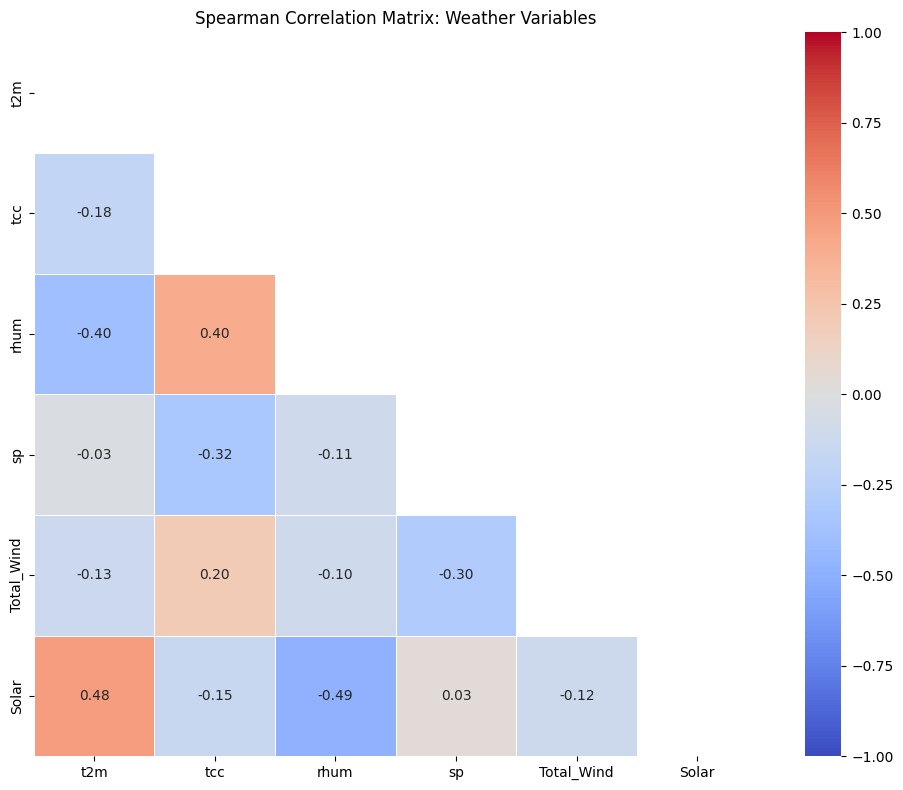

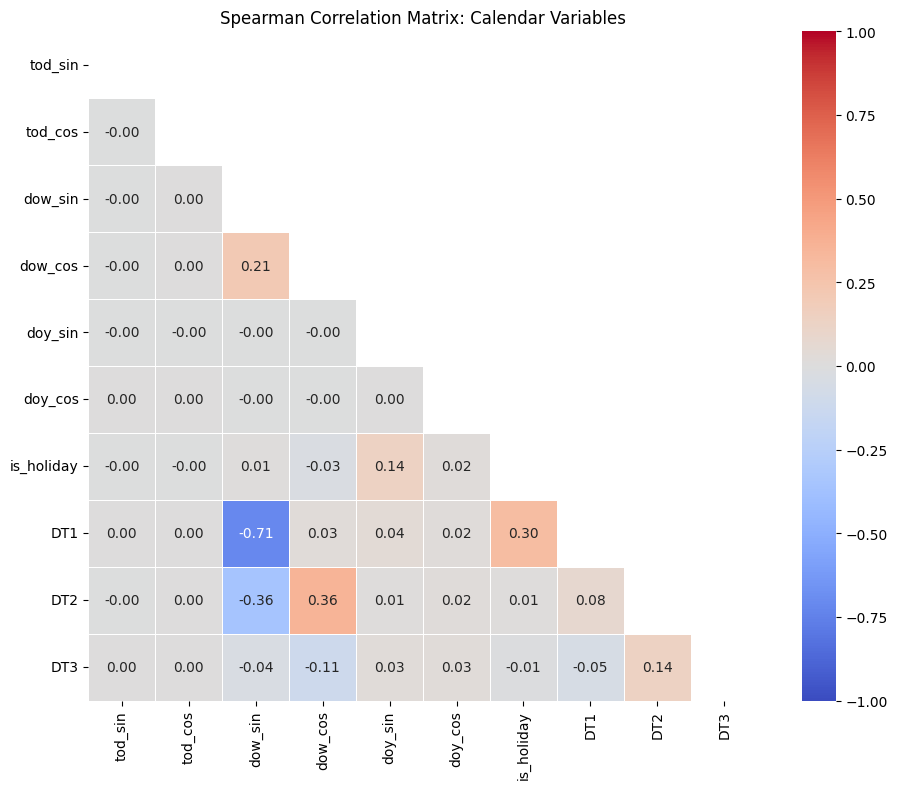


2. Calculating Variance Inflation Factors...

--- VIF Analysis: Weather Variables ---
(Target: VIF < 5. Warning: VIF > 10)
   Feature      VIF
      rhum 1.930943
     Solar 1.701221
       t2m 1.380558
       tcc 1.325112
Total_Wind 1.236628
        sp 1.202292

--- VIF Analysis: Calendar Variables ---
(Target: VIF < 5. Warning: VIF > 10)
   Feature      VIF
       DT1 4.629508
   dow_sin 3.827750
       DT2 2.493138
   dow_cos 2.354889
is_holiday 1.598210
       DT3 1.071508
   doy_sin 1.018376
   doy_cos 1.001380
   tod_cos 1.000001
   tod_sin 1.000000

--- VIF Analysis: Combined Matrix (The Overshadowing Test) ---
(Target: VIF < 5. Warning: VIF > 10)
   Feature      VIF
       t2m 5.510852
   doy_cos 4.921939
       DT1 4.630676
   dow_sin 3.833762
     Solar 3.347399
      rhum 2.755517
       DT2 2.496360
   dow_cos 2.356870
   tod_cos 2.267478
   doy_sin 1.733778
is_holiday 1.612096
   tod_sin 1.598628
       tcc 1.468709
Total_Wind 1.360868
        sp 1.237868
       DT3 1.075

In [ ]:
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# ==========================================
# 1. DEFINE YOUR FEATURE GROUPS
# ==========================================
weather_features = thermal_drivers + generation_features

df_diag = df.dropna()

# ==========================================
# 2. SPEARMAN CORRELATION MATRIX (Non-Linear)
# ==========================================
def plot_spearman(features, title):
    plt.figure(figsize=(10, 8))
    # calculate Spearman (Rank) Correlation
    corr_matrix = df_diag[features].corr(method='spearman')
    
    # create a mask to hide the upper triangle for readability
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", 
                cmap='coolwarm', vmin=-1, vmax=1, center=0,
                square=True, linewidths=.5)
    plt.title(f'Spearman Correlation Matrix: {title}')
    plt.tight_layout()
    plt.show()

# plot them separately
print("1. Generating Correlation Matrices...")
plot_spearman(weather_features, "Weather Variables")
plot_spearman(calendar_features, "Calendar Variables")

# ==========================================
# 3. VARIANCE INFLATION FACTOR (VIF)
# ==========================================
def calculate_vif(features, name):
    # VIF requires a constant (intercept) column to calculate R-squared correctly
    X = add_constant(df_diag[features])
    
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X.columns
    
    # calc VIF for each feature
    vif_data["VIF"] = [
        variance_inflation_factor(X.values, i) 
        for i in range(X.shape[1])
    ]
    
    # drop constants
    vif_data = vif_data[vif_data['Feature'] != 'const'].sort_values(by="VIF", ascending=False)
    
    print(f"\n--- VIF Analysis: {name} ---")
    print("(Target: VIF < 5. Warning: VIF > 10)")
    print(vif_data.to_string(index=False))
    return vif_data

print("\n2. Calculating Variance Inflation Factors...")
vif_weather = calculate_vif(weather_features, "Weather Variables")
vif_calendar = calculate_vif(calendar_features, "Calendar Variables")
vif_combined = calculate_vif(weather_features + calendar_features, "Combined Matrix (The Overshadowing Test)")

In [8]:
from neuralforecast.losses.pytorch import MSE

In [ ]:
df['Wind_Log'] = np.log1p(df['Total_Wind'])

noise_threshold = 0.1 

# If physical solar generation exceeds the noise floor, keep it. 
# Otherwise, force it to absolute zero.
df['Solar_Gated'] = np.where(df['Solar'] > noise_threshold, df['Solar'], 0.0)

df['Solar_Log'] = np.log1p(df['Solar_Gated'])

In [11]:
cal_features = ['tod_sin', 'tod_cos', 'dow_sin', 'dow_cos' ,'doy_sin', 'doy_cos', 'DT1','DT2', 'DT3']
wea_gen_features = ['t2m','Total_Wind','Solar_Log']

In [ ]:
from neuralforecast.losses.pytorch import HuberLoss


# ==========================================
# MERGING & ALIGNING THE FULL DATASET
# ==========================================
print("1. Preparing Full Operational Dataset...")

full_features = ['tod_sin', 'tod_cos', 'dow_sin', 'dow_cos' ,'doy_sin', 'doy_cos', 'DT1','DT2', 'DT3',
                 't2m', 'Total_Wind', 'Solar_Log']


last_date = df['ds'].dt.date.max()
dam_cutoff_end = pd.to_datetime(f"{last_date} 11:00:00")
df_full_aligned = df[df['ds'] <= dam_cutoff_end].copy()

BEST_PARAMS = {
    'input_size': 168,           
    'hidden_size': 256,          
    'temporal_ff': 512,          
    'channel_ff': 16,            
    'batch_size': 128,            
    'temporal_dropout': 0.3,     
    'channel_dropout': 0,      
    'learning_rate': 0.00028     
}

1. Preparing Full Operational Dataset...


In [30]:
CAL_PARAMS = {
    'input_size': 168,           
    'hidden_size': 448,          
    'temporal_ff': 384,          
    'channel_ff': 8,            
    'batch_size': 256,            
    'temporal_dropout': 0.2,     
    'channel_dropout': 0,      
    'learning_rate': 0.0009     
}
WEA_GEN_PARAMS = {
    'input_size': 168,           
    'hidden_size': 320,          
    'temporal_ff': 384,          
    'channel_ff': 20,            
    'batch_size': 256,            
    'temporal_dropout': 0.2,     
    'channel_dropout': 0,      
    'learning_rate': 0.00045     
}
UNI_PARAMS = {
    'input_size': 168,           
    'hidden_size': 384,          
    'temporal_ff': 128,          
    'channel_ff': 20,            
    'batch_size': 16,            
    'temporal_dropout': 0.1,     
    'channel_dropout': 0,      
    'learning_rate': 0.0009     
}
ALL_PARAMS = {
    'input_size': 168,           
    'hidden_size': 448,          
    'temporal_ff': 384,          
    'channel_ff': 8,            
    'batch_size': 64,            
    'temporal_dropout': 0.3,     
    'channel_dropout': 0,      
    'learning_rate': 0.00057    
}

In [33]:
PARAMS = BEST_PARAMS

Seed set to 42


2. Initializing Optimal XLinear Model...
3. Executing 56-Day Causal Rolling Cross-Validation...


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name                 | Type          | Params | Mode 
---------------------------------------------------------------
0 | loss                 | MSE           | 0      | train
1 | padder_train         | ConstantPad1d | 0      | train
2 | scaler               | TemporalNorm  | 0      | train
3 | projection           | Sequential    | 43.3 K | train
4 | temporal_gating      | GatingBlock   | 525 K  | train
5 | channel_gating       | GatingBlock   | 82     | train
6 | futr_exog_projection | Linear        | 626 K  | train
7 | head                 | Sequential    | 27.7 K | train
  | other params         | n/a           | 256    | n/a  
---------------------------------------------------------------
1.2 M     Trainable params
0         Non-trainable params
1.2 M     Total params
4.894     Total estimated model params size (MB)
24        Modules in train mode
0         Modules 

4. Calculating Final DAM Performance Metrics...

=== FINAL OPERATIONAL DAM BASELINE (XLinear) ===
Total MAPE: 3.56%
Total MAE:  117.15 MW
Total RMSE: 177.00 MW


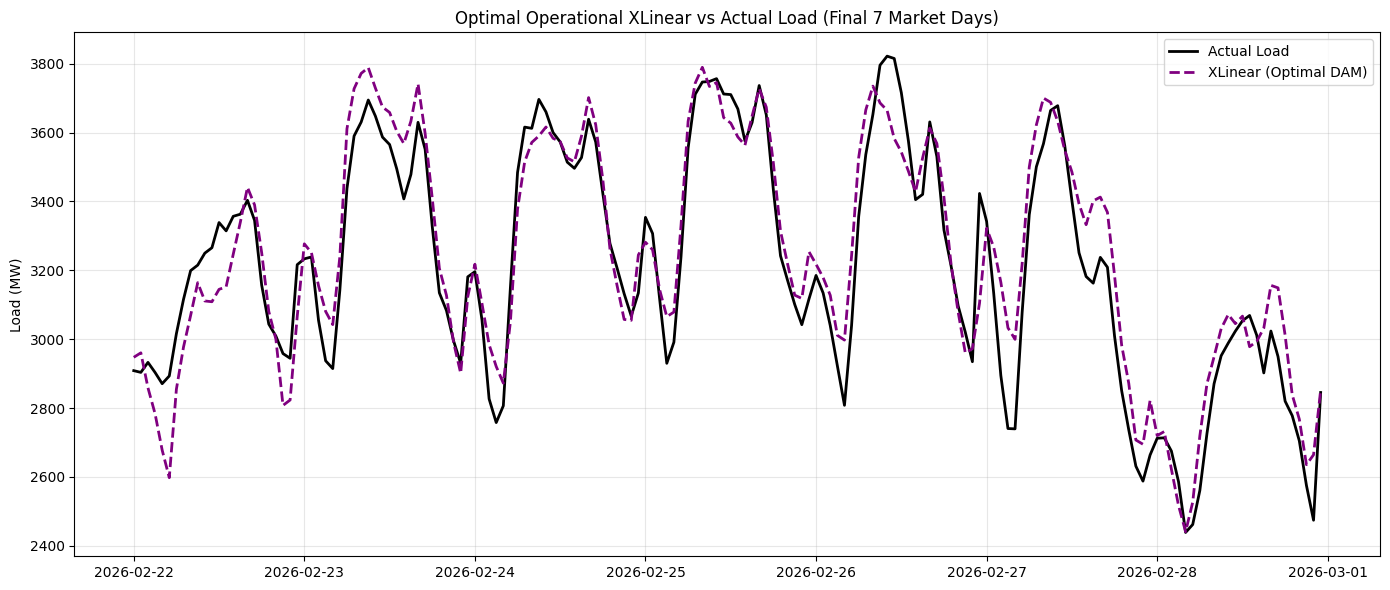

In [ ]:

print("2. Initializing Optimal XLinear Model...")
final_model = XLinear(
    h=36, 
    input_size=PARAMS['input_size'], 
    n_series=1,
    futr_exog_list=full_features, 
    
    hidden_size=PARAMS['hidden_size'],
    temporal_ff=PARAMS['temporal_ff'],
    channel_ff=PARAMS['channel_ff'],
    batch_size=PARAMS['batch_size'],
    
    temporal_dropout=PARAMS['temporal_dropout'],
    channel_dropout=PARAMS['channel_dropout'],
    learning_rate=PARAMS['learning_rate'],
    
    loss=MSE(),
    max_steps=3000, 
    scaler_type='standard',
    random_seed=42,
    enable_progress_bar=False,
    val_check_steps=50,
    early_stop_patience_steps=20,

)

nf_final = NeuralForecast(models=[final_model], freq='h')

# ==========================================
# TS-CV
# ==========================================
print("3. Executing 56-Day Causal Rolling Cross-Validation...")
cv_df_final = nf_final.cross_validation(
    df=df_full_aligned,
    n_windows=56,      
    step_size=24,
    val_size=24*7
)

# ==========================================
# MARKET SLICE & EVALUATION
# ==========================================
print("4. Calculating Final DAM Performance Metrics...")
# Extract the 24-hour bid following the 12-hour blind spot
cv_df_final['market_date'] = (cv_df_final['cutoff'] + pd.Timedelta(days=1)).dt.date
market_cv_final = cv_df_final[cv_df_final['ds'].dt.date == cv_df_final['market_date']].copy()


error_final = market_cv_final['y'] - market_cv_final['XLinear']
abs_error_final = error_final.abs()

# Calculate metrics
mape_final = (abs_error_final / market_cv_final['y'].abs()).mean() * 100
mae_final = abs_error_final.mean()
rmse_final = (error_final ** 2).mean() ** 0.5

print(f"\n=== FINAL OPERATIONAL DAM BASELINE (XLinear) ===")
print(f"Total MAPE: {mape_final:.2f}%")
print(f"Total MAE:  {mae_final:.2f} MW")
print(f"Total RMSE: {rmse_final:.2f} MW")

# ==========================================
# VISUALIZATION
# ==========================================
plot_slice = 24 * 7
plot_df_final = market_cv_final.tail(plot_slice).set_index('ds')

plt.figure(figsize=(14, 6))
plt.plot(plot_df_final.index, plot_df_final['y'], label='Actual Load', color='black', linewidth=2)
plt.plot(plot_df_final.index, plot_df_final['XLinear'], label='XLinear (Optimal DAM)', color='purple', linestyle='--', linewidth=2)
plt.title('Optimal Operational XLinear vs Actual Load (Final 7 Market Days)')
plt.ylabel('Load (MW)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [41]:
market_cv_final

,unique_id,ds,cutoff,Forecast_MW,y,market_date,Model_ID,date
0,DK_Grid,2026-01-04 00:00:00,2026-01-03 23:00:00,2942.086914,2929.1350,2026-01-04,full,2026-01-04
1,DK_Grid,2026-01-04 01:00:00,2026-01-03 23:00:00,2940.192383,2912.7125,2026-01-04,full,2026-01-04
2,DK_Grid,2026-01-04 02:00:00,2026-01-03 23:00:00,2873.770508,2850.3125,2026-01-04,full,2026-01-04
3,DK_Grid,2026-01-04 03:00:00,2026-01-03 23:00:00,2858.727783,2804.7800,2026-01-04,full,2026-01-04
4,DK_Grid,2026-01-04 04:00:00,2026-01-03 23:00:00,2752.261719,2706.7875,2026-01-04,full,2026-01-04
...,...,...,...,...,...,...,...,...
1999,DK_Grid,2026-02-28 19:00:00,2026-02-27 23:00:00,2838.517822,2778.0350,2026-02-28,full,2026-02-28
2000,DK_Grid,2026-02-28 20:00:00,2026-02-27 23:00:00,2767.595703,2704.8225,2026-02-28,full,2026-02-28
2001,DK_Grid,2026-02-28 21:00:00,2026-02-27 23:00:00,2635.736084,2575.5175,2026-02-28,full,2026-02-28
2002,DK_Grid,2026-02-28 22:00:00,2026-02-27 23:00:00,2664.442627,2474.4650,2026-02-28,full,2026-02-28


In [ ]:
import os

# ==========================================
# EXPORT
# ==========================================

stage = 'full'
market_cv_final['Model_ID'] = stage 

market_cv_final.rename(columns={'XLinear': 'Forecast_MW'}, inplace=True)

export_filename = f"xlinear_results_{stage}.csv"
market_cv_final.to_csv(export_filename, index=False)

print(f"Results successfully logged to {export_filename}")

Results successfully logged to xlinear_results_full.csv


In [ ]:
nf_final.save(path='./production_models//xlinear_dk1_3', overwrite=True)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

print("Extracting and Aligning Training Logs...")

try:
    metrics = pd.read_csv('logs/xlinear_cv/version_48/metrics.csv')
    
    # Extract Training (Scaled)
    train_logs = metrics[['step', 'train_loss_step']].dropna()
    train_logs['smoothed_train'] = train_logs['train_loss_step'].rolling(window=10, min_periods=1).mean()

    # Extract Validation (Unscaled MW)
    val_logs = metrics[['step', 'valid_loss']].dropna()

    # ==========================================
    # DUAL-AXIS PLOTTING
    # ==========================================
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Left Axis: Training 
    color1 = '#3498db'
    ax1.set_xlabel('Training Steps', fontsize=12)
    ax1.set_ylabel('Training Loss (Scaled)', color=color1, fontsize=12)
    ax1.plot(train_logs['step'], train_logs['smoothed_train'], label='Training Loss (Smoothed)', color=color1, linewidth=2.5)
    ax1.plot(train_logs['step'], train_logs['train_loss_step'], color=color1, alpha=0.15)
    ax1.tick_params(axis='y', labelcolor=color1)

    # Right Axis: Validation
    ax2 = ax1.twinx()  
    color2 = '#e74c3c'
    ax2.set_ylabel('Validation Loss (Raw MAE)', color=color2, fontsize=12)
    ax2.plot(val_logs['step'], val_logs['valid_loss'], label='Validation Loss', color=color2, linewidth=2.5, marker='o')
    ax2.tick_params(axis='y', labelcolor=color2)

    plt.title('XLinear Learning Curve (Dual-Axis Alignment)', fontsize=14, fontweight='bold')
    
    # Combine legends from both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=12, loc='upper right')

    ax1.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()

except FileNotFoundError:
    print("Log file not found. Ensure the path matches the CSVLogger save_dir.")

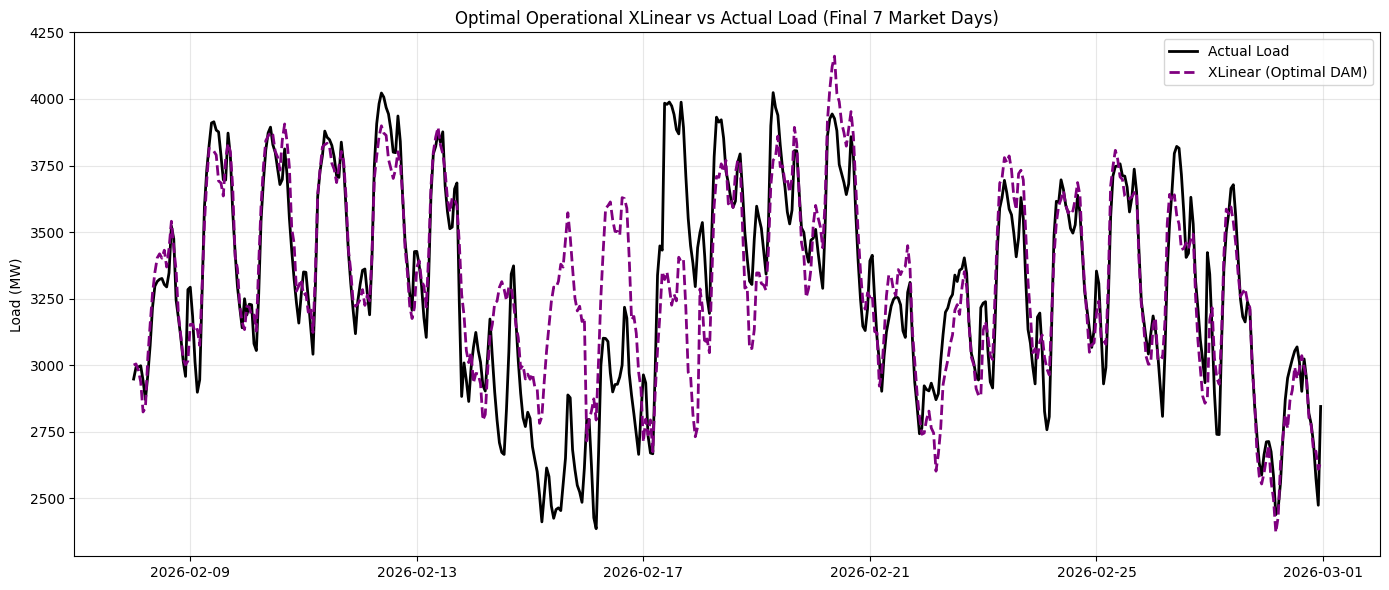

In [ ]:
plot_slice = 24 * 21
plot_df_final = market_cv_final.tail(plot_slice).set_index('ds')

plt.figure(figsize=(14, 6))
plt.plot(plot_df_final.index, plot_df_final['y'], label='Actual Load', color='black', linewidth=2)
plt.plot(plot_df_final.index, plot_df_final['XLinear'], label='XLinear (Optimal DAM)', color='purple', linestyle='--', linewidth=2)
plt.title('Optimal Operational XLinear vs Actual Load (Final 7 Market Days)')
plt.ylabel('Load (MW)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

C:\Users\Benedek\AppData\Local\Temp\ipykernel_16364\3174722747.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hourly_err.index, y=hourly_err.values, palette='viridis')


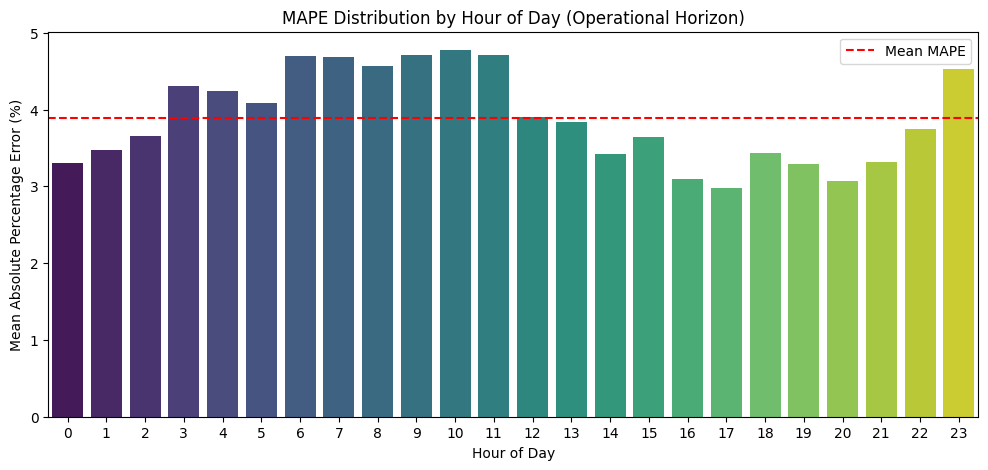

Worst Hour for Error: Hour 10 (4.77%)
Best Hour for Error:  Hour 17 (2.98%)


In [ ]:
# hourly MAPE
cv_df_final['hour'] = cv_df_final['ds'].dt.hour
cv_df_final['ape'] = 100 * (cv_df_final['y'] - cv_df_final['XLinear']).abs() / cv_df_final['y']

hourly_err = cv_df_final.groupby('hour')['ape'].mean()

# Plot
plt.figure(figsize=(12, 5))
sns.barplot(x=hourly_err.index, y=hourly_err.values, palette='viridis')
plt.axhline(hourly_err.mean(), color='red', linestyle='--', label='Mean MAPE')
plt.title('MAPE Distribution by Hour of Day (Operational Horizon)')
plt.ylabel('Mean Absolute Percentage Error (%)')
plt.xlabel('Hour of Day')
plt.legend()
plt.show()

print(f"Worst Hour for Error: Hour {hourly_err.idxmax()} ({hourly_err.max():.2f}%)")
print(f"Best Hour for Error:  Hour {hourly_err.idxmin()} ({hourly_err.min():.2f}%)")

In [49]:
import pandas as pd
from entsoe import EntsoePandasClient

df_entso = pd.read_csv('D:\Downloads\GUI_TOTAL_LOAD_DAYAHEAD_202601010000-202701010000.csv')
df_entso = df_entso.rename(columns={'MTU (UTC)':'ds'})

<>:4: SyntaxWarning: invalid escape sequence '\D'
<>:4: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Benedek\AppData\Local\Temp\ipykernel_17028\1513703759.py:4: SyntaxWarning: invalid escape sequence '\D'
  df_entso = pd.read_csv('D:\Downloads\GUI_TOTAL_LOAD_DAYAHEAD_202601010000-202701010000.csv')


In [ ]:
import numpy as np

numeric_cols = ['Actual Total Load (MW)', 'Day-ahead Total Load Forecast (MW)']

for col in numeric_cols:
    df_entso[col] = pd.to_numeric(df_entso[col], errors='coerce').astype('float32')

actuals = df_entso['Actual Total Load (MW)']
forecasts = df_entso['Day-ahead Total Load Forecast (MW)']

# APE / row
df_entso['absolute_error'] = np.abs(actuals - forecasts)
df_entso['ape'] = df_entso['absolute_error'] / actuals

# Calculate MAPE
entsoe_mape = df_entso['ape'].mean() * 100

print(f"=========================================================")
print(f"Official ENTSO-E Day-Ahead Forecast MAPE: {entsoe_mape:.3f}%")
print(f"=========================================================")

Official ENTSO-E Day-Ahead Forecast MAPE: 3.021%


In [51]:
df_entso['ds'] = df_entso['ds'].str.split(' - ').str[0]
df_entso['ds'] = pd.to_datetime(df_entso['ds'], format='%d/%m/%Y %H:%M')

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Extract the physical date
market_cv_final['date'] = market_cv_final['ds'].dt.date

#Function to calc metrics
def calculate_daily_errors(df_day):
    y_true = df_day['y']
    y_pred = df_day['Forecast_MW']
    
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    
    return pd.Series({
        'MAE_MW': np.round(mae, 2),
        'RMSE_MW': np.round(rmse, 2),
        'MAPE_%': np.round(mape, 3)
    })

# Group by date, calculate error metrics
daily_performance = market_cv_final.groupby('date').apply(calculate_daily_errors).reset_index()

# Sort to get worst values
top_10_worst = daily_performance.sort_values(by='MAPE_%', ascending=False).head(10)

top_10_worst = top_10_worst.reset_index(drop=True)

print("--- Top 10 Worst Performing Days (Day-Ahead Market) ---")
print(top_10_worst.to_string())

--- Top 10 Worst Performing Days (Day-Ahead Market) ---
         date  MAE_MW  RMSE_MW  MAPE_%
0  2026-02-15  623.50   660.20  24.246
1  2026-02-17  520.37   599.11  14.180
2  2026-02-16  303.02   335.41  10.413
3  2026-01-05  309.22   347.01   8.502
4  2026-02-14  199.27   274.24   7.064
5  2026-01-24  200.32   206.86   6.257
6  2026-02-27  138.61   156.93   4.600
7  2026-01-14  144.70   162.07   4.353
8  2026-02-13  139.11   174.64   4.289
9  2026-02-04  169.80   184.84   4.232


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# outlier dates
outlier_dates = pd.to_datetime([
    '2026-02-14', 
    '2026-02-15', 
    '2026-02-16', 
    '2026-02-17', 
    '2026-01-05'
]).date

if 'date' not in market_cv_final.columns:
    market_cv_final['date'] = market_cv_final['ds'].dt.date

# exclude these 5 specific days
cleaned_cv_df = market_cv_final[~market_cv_final['date'].isin(outlier_dates)].copy()

# Col name
pred_col = 'Forecast_MW' if 'Forecast_MW' in cleaned_cv_df.columns else 'XLinear'

y_true_clean = cleaned_cv_df['y']
y_pred_clean = cleaned_cv_df[pred_col]

# calculate metrics
mae_clean = mean_absolute_error(y_true_clean, y_pred_clean)
rmse_clean = np.sqrt(mean_squared_error(y_true_clean, y_pred_clean))
mape_clean = mean_absolute_percentage_error(y_true_clean, y_pred_clean) * 100

# Output results
removed_hours = len(market_cv_final) - len(cleaned_cv_df)
print(f"--- Cleaned OOS Evaluation (Excluding {len(outlier_dates)} Outlier Days) ---")
print(f"Data volume: {len(cleaned_cv_df)} hours evaluated ({removed_hours} hours removed)")
print("-" * 55)
print(f"Clean MAE:  {mae_clean:.2f} MW")
print(f"Clean RMSE: {rmse_clean:.2f} MW")
print(f"Clean MAPE: {mape_clean:.3f} %")

--- Cleaned OOS Evaluation (Excluding 5 Outlier Days) ---
Data volume: 1224 hours evaluated (120 hours removed)
-------------------------------------------------------
Clean MAE:  90.30 MW
Clean RMSE: 113.02 MW
Clean MAPE: 2.652 %
